<a href="https://colab.research.google.com/github/andi-trilleras/ModelosAnaliticosUnicafam202607/blob/main/ParcialKmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Taller K-Means

Diplomado en analítica de datos

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
dataset=pd.read_excel("/content/sample_data/crime_data.xlsx")

In [7]:
X = dataset.iloc[:, [1, 2, 4]].values

In [8]:
X

array([[ 13.2, 236. ,  21.2],
       [ 10. , 263. ,  44.5],
       [  8.1, 294. ,  31. ],
       [  8.8, 190. ,  19.5],
       [  9. , 276. ,  40.6],
       [  7.9, 204. ,  38.7],
       [  3.3, 110. ,  11.1],
       [  5.9, 238. ,  15.8],
       [ 15.4, 335. ,  31.9],
       [ 17.4, 211. ,  25.8],
       [  5.3,  46. ,  20.2],
       [  2.6, 120. ,  14.2],
       [ 10.4, 249. ,  24. ],
       [  7.2, 113. ,  21. ],
       [  2.2,  56. ,  11.3],
       [  6. , 115. ,  18. ],
       [  9.7, 109. ,  16.3],
       [ 15.4, 249. ,  22.2],
       [  2.1,  83. ,   7.8],
       [ 11.3, 300. ,  27.8],
       [  4.4, 149. ,  16.3],
       [ 12.1, 255. ,  35.1],
       [  2.7,  72. ,  14.9],
       [ 16.1, 259. ,  17.1],
       [  9. , 178. ,  28.2],
       [  6. , 109. ,  16.4],
       [  4.3, 102. ,  16.5],
       [ 12.2, 252. ,  46. ],
       [  2.1,  57. ,   9.5],
       [  7.4, 159. ,  18.8],
       [ 11.4, 285. ,  32.1],
       [ 11.1, 254. ,  26.1],
       [ 13. , 337. ,  16.1],
       [  

In [9]:
from sklearn.preprocessing import StandardScaler
escalar = StandardScaler()
X_escalada = escalar.fit_transform(X)

Text(0.5, 0, 'Clusters')

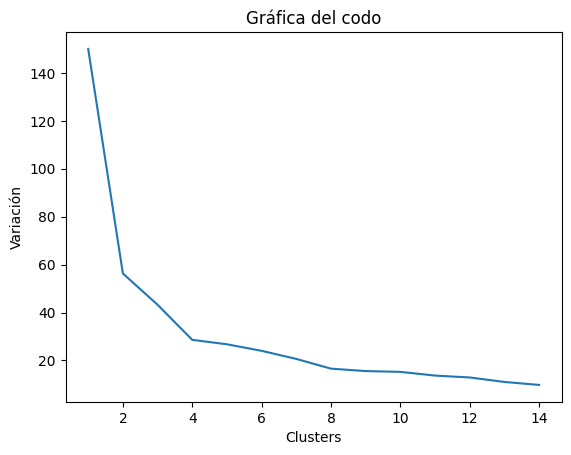

In [10]:
from sklearn.cluster import KMeans
lista=[]
for i in range(1,15):
  kmeans=KMeans(n_clusters=i,init="k-means++",random_state=42)
  kmeans.fit(X_escalada)
  lista.append(kmeans.inertia_)

#Gráfica del codo
plt.plot(range(1,15),lista)
plt.title("Gráfica del codo")
plt.ylabel("Variación")
plt.xlabel("Clusters")

In [11]:
kmeans=KMeans(n_clusters=3,init="k-means++",random_state=42)
y_kmeans=kmeans.fit_predict(X_escalada)

In [12]:
X_escalada

array([[ 1.25517927,  0.79078716, -0.00345116],
       [ 0.51301858,  1.11805959,  2.50942392],
       [ 0.07236067,  1.49381682,  1.05346626],
       [ 0.23470832,  0.23321191, -0.18679398],
       [ 0.28109336,  1.2756352 ,  2.08881393],
       [ 0.02597562,  0.40290872,  1.88390137],
       [-1.04088037, -0.73648418, -1.09272319],
       [-0.43787481,  0.81502956, -0.58583422],
       [ 1.76541475,  1.99078607,  1.1505301 ],
       [ 2.22926518,  0.48775713,  0.49265293],
       [-0.57702994, -1.51224105, -0.11129987],
       [-1.20322802, -0.61527217, -0.75839217],
       [ 0.60578867,  0.94836277,  0.29852525],
       [-0.13637203, -0.70012057, -0.0250209 ],
       [-1.29599811, -1.39102904, -1.07115345],
       [-0.41468229, -0.67587817, -0.34856705],
       [ 0.44344101, -0.74860538, -0.53190987],
       [ 1.76541475,  0.94836277,  0.10439756],
       [-1.31919063, -1.06375661, -1.44862395],
       [ 0.81452136,  1.56654403,  0.70835037],
       [-0.78576263, -0.26375734, -0.531

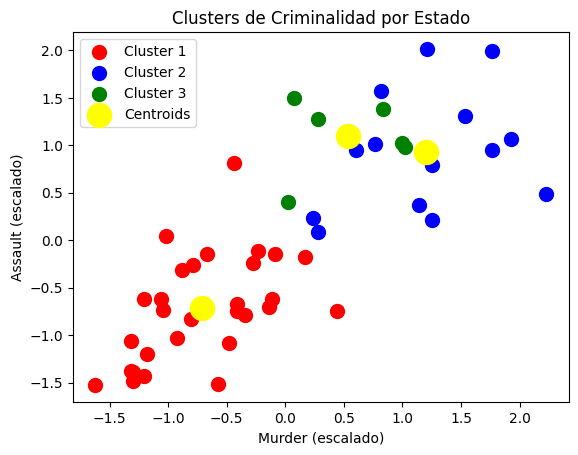

In [13]:
plt.scatter(X_escalada[y_kmeans == 0, 0], X_escalada[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X_escalada[y_kmeans == 1, 0], X_escalada[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X_escalada[y_kmeans == 2, 0], X_escalada[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Clusters de Criminalidad por Estado')
plt.xlabel('Murder (escalado)')
plt.ylabel('Assault (escalado)')
plt.legend()
plt.show()

In [14]:
dataset["Clusters"]=y_kmeans
dataset

,Unnamed: 0,Murder,Assault,UrbanPop,Rape,Clusters
0,Alabama,13.2,236,58,21.2,1
1,Alaska,10.0,263,48,44.5,2
2,Arizona,8.1,294,80,31.0,2
3,Arkansas,8.8,190,50,19.5,1
4,California,9.0,276,91,40.6,2
5,Colorado,7.9,204,78,38.7,2
6,Connecticut,3.3,110,77,11.1,0
7,Crime,5.9,238,72,15.8,0
8,Florida,15.4,335,80,31.9,1
9,Georgia,17.4,211,60,25.8,1


In [15]:
dataset.to_csv("Resultados-crimedata.csv",index=False)

¿Cómo podemos agrupar los estados?


Para agrupar los estados fue necesario escalar los datos de Assault, Murder y Rape. Tomé el 3 como K ya que hay tres tipos de recursos policiales. Se tienen entonces tres clusteres con nivel de criminalidad.

¿Cuáles son los estados con necesidad de profesionales con mayor capacidad de atención al crimen?

Según la gráfica, los estados con mayor necesidad de profesionales conn mayor capacidad de crimen son los que estan en el cluster 3: Alaska, Arizona, California, Colorado, Michigan, Nevada y New Mexico.

¿Cómo distribuiría los recursos?

Tanto para el cluster 2 como el tres, asignaria en la misma cantidad los 300 policias capacitados; sin embargo asignaria también 300 policias de a pie en el cluster 3 donde se presentan mas asaltos y los 200 restantes en el cluster 2. Los cadetes serian asignados en el cluster 1 donde hay 29 estados pero los indicadores son mas bajos.

¿Cuáles son los grupos que existen dentro del comportamiento de la criminalidad?

En el grupo de alta complejidad se encuentra Assault y Rape. En el de complejidad media igualmente Assault y Rape y por último, en el de baja complejidad hay una mezcla de Assault, Rape y Murder pero los valores son significativamente mas bajos.

Recomendaciones finales:

*   Concentrar al personal mas especializado en los clusteres 2 y 3 ya que alli se concentra la alta y media complejidad de criminalidad registrada.
*   Mantener a los cadetes en el cluster 1, sin embargo se debe monitorear el comportamiento de los datos periódicamente para analizar la efectividad de esa clusterizacion.



